In [1]:
!pip install langchain-huggingface

In [2]:
import os
from google.colab import userdata

# 1. Get the key from Colab Secrets
api_key = userdata.get("APIKEY")

# 2. Set it as an environment variable (Crucial step)
os.environ["HUGGINGFACEHUB_API_TOKEN"] = api_key


In [3]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict,Literal
from pydantic import BaseModel,Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.prompts import PromptTemplate

In [4]:
load_dotenv()

llm =HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)

model = ChatHuggingFace(llm = llm)

model.invoke("Hey")

AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 36, 'total_tokens': 57}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': 'fp_f613d2b18eccee549c5f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3005-974f-7622-93f7-2dad524e3c9a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})

# **The biggest difference: BaseModel → does runtime validation TypedDict → only gives type hints (no real checking at runtime)**

In [26]:
class Sentimentstate(BaseModel):
    sentiment: Literal["positive", "negative"]

In [27]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [28]:
class Reviewstate(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str


# **I am using the pydantic output parser as i am using the hugging face meta llama 7 billion paramater,we can not use this model with structured output parser because are just text generators.They do not natively support tool calling / function calling / JSON mode like OpenAI GPT models do.**

In [29]:
parser1 = PydanticOutputParser(pydantic_object = Sentimentstate)
parser2 = PydanticOutputParser(pydantic_object = DiagnosisSchema)

In [30]:
prompt1 = PromptTemplate(
    template="""You are a strict JSON-only generator. Do not include any introductory or concluding text, or conversational filler. Return only the valid JSON object.

{format_instructions}

What is the sentiment of the following review:
"{review}"
""",
    input_variables=["review"],
    partial_variables={"format_instructions": parser1.get_format_instructions()}
)

In [31]:

template = "{issue} {format_instructions}"

prompt2 = PromptTemplate(
    template=template,
    input_variables=["issue"],
    partial_variables={"format_instructions": parser2.get_format_instructions()}


)

In [32]:
structured_output1 = prompt1 | model | parser1

In [33]:
structured_output2 = prompt2 | model | parser2

In [34]:
review = "the software is good"
issue = """The app keeps crashing whenever I try to upload a file.
It has become very slow after the latest update, and I am unable to complete my work on time.
I already contacted support twice but received no response.
This is extremely frustrating and needs to be fixed immediately."""

In [35]:

structured_output1.invoke({"review":review})

Sentimentstate(sentiment='positive')

In [36]:
structured_output2.invoke({"issue":issue})

DiagnosisSchema(issue_type='Performance', tone='frustrated', urgency='high')

In [37]:
def find_sentiment(state:Reviewstate):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_output1.invoke(prompt).sentiment
    return {"sentiment":sentiment}

def check_sentiment(state:Reviewstate) -> Literal["positive_responce", "run_diagnosis"]:

    if state["sentiment"] == "positive":
        return "positive_responce"
    else:
        return "run_diagnosis"

def positive_responce(state:Reviewstate):

    prompt = f"""Write a warm thank-you message in response to this review:
            \n\n\"{state['review']}\"\n
            Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {"response":response}

def run_diagnosis(state:Reviewstate):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\nReturn issue_type, tone, and urgency."""
    response = structured_output2.invoke(prompt)
    return {'diagnosis': response.model_dump()}

def negative_response(state: Reviewstate):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [38]:
graph = StateGraph(Reviewstate)

In [39]:
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_responce",positive_responce)
graph.add_node("negative_response",negative_response)

In [40]:
graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("positive_responce",END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

In [41]:
workflow = graph.compile()

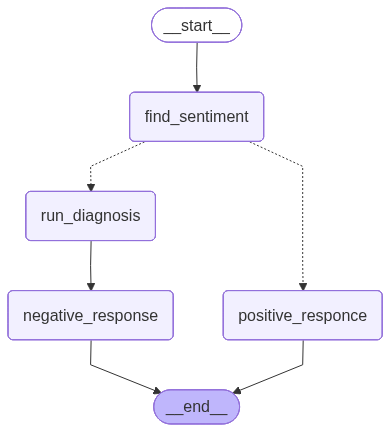

In [42]:
workflow

In [43]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: Re: Urgent: Bug Issue - High Priority\n\nDear [Username],\n\nI can sense the frustration in your message, and I want to assure you that we're taking your issue seriously. I've been assigned to assist you with the bug you're experiencing, and I'll do my best to resolve it as quickly as possible.\n\nTo better understand the issue, could you please provide me with more details about what's happening? This will help me to better assess the situation and suggest a solution. Please feel free to share the following information:\n\n- A clear description of the bug you're experiencing\n- The steps you've taken so far to troublesh